<a href="https://colab.research.google.com/github/Ignacioruuizm/EXAMEN_BD_MACHINEL_CSGO/blob/EV3/Comparativas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, roc_auc_score, classification_report)
from sklearn.preprocessing import StandardScaler

In [4]:
# Cargar los datos
from google.colab import files
uploaded = files.upload()

# Intenta detectar delimitador automáticamente
try:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', low_memory=False)
except pd.errors.ParserError:
    df = pd.read_csv('Anexo ET_demo_round_traces_2022.csv', sep=';', low_memory=False)

# Eliminar columna de índice innecesaria si existe
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Asignar nombres correctos a las columnas si corresponde
column_names = [
    'PlayerId', 'Map', 'Team', 'InternalTeamId', 'MatchId', 'RoundId', 'RoundWinner',
    'MatchWinner', 'Survived', 'AbnormalMatch', 'TimeAlive', 'TravelledDistance',
    'RLethalGrenadesThrown', 'RNonLethalGrenadesThrown', 'PrimaryAssaultRifle',
    'PrimarySniperRifle', 'PrimaryHeavy', 'PrimarySMG', 'PrimaryPistol', 'FirstKillTime',
    'RoundKills', 'RoundAssists', 'RoundHeadshots', 'RoundFlankKills',
    'RoundStartingEquipmentValue', 'TeamStartingEquipmentValue', 'MatchKills',
    'MatchFlankKills', 'MatchAssists', 'MatchHeadshots']

if len(df.columns) == len(column_names):
    df.columns = column_names

# Selección de características relevantes
features = [
    'TeamStartingEquipmentValue',
    'RoundStartingEquipmentValue',
    'TimeAlive',
    'TravelledDistance',
    'RoundAssists',
    'RoundHeadshots'
]

# Conversión a numérico con control
for col in features + ['MatchKills']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Total antes de imputación: {df.shape}")

# Imputación de valores faltantes con la mediana
df[features + ['MatchKills']] = df[features + ['MatchKills']].fillna(df[features + ['MatchKills']].median())

print(f"Total después de imputación: {df.shape}")

# Crear variable objetivo ajustada
umbral = 3
df['HighKills'] = (df['MatchKills'] >= umbral).astype(int)
print(df['HighKills'].value_counts())

# Dividir datos sin forzar balanceo
X = df[features]
y = df['HighKills']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Saving Anexo ET_demo_round_traces_2022.csv to Anexo ET_demo_round_traces_2022 (4).csv
Total antes de imputación: (79157, 29)
Total después de imputación: (79157, 29)
HighKills
1    64068
0    15089
Name: count, dtype: int64


### Resultados para Árbol de Decisión:
Accuracy: 0.6482

Matriz de Confusión:
[[1680 1338]
 [4232 8582]]
### Reporte de Clasificación - Árbol de Decisión ###
              precision    recall  f1-score   support

           0       0.28      0.56      0.38      3018
           1       0.87      0.67      0.75     12814

    accuracy                           0.65     15832
   macro avg       0.57      0.61      0.57     15832
weighted avg       0.75      0.65      0.68     15832



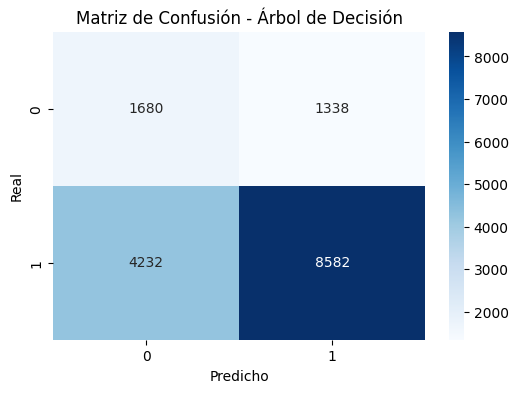

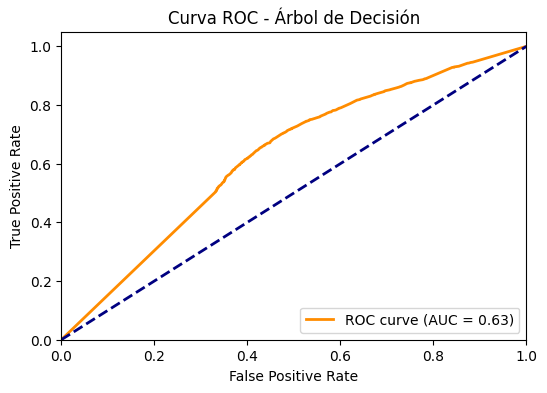

In [5]:
from sklearn.tree import DecisionTreeClassifier

# Definición del modelo Árbol de Decisión
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_model.fit(X_train, y_train)

# Predicciones
y_pred_dt = dt_model.predict(X_test)
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]

# Métricas
print("### Resultados para Árbol de Decisión:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_dt))
print("### Reporte de Clasificación - Árbol de Decisión ###")
print(classification_report(y_test, y_pred_dt))
print("="*50)

# Matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_dt)
roc_auc = roc_auc_score(y_test, y_proba_dt)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC - Árbol de Decisión')
plt.legend(loc="lower right")
plt.show()

### Resultados para KNN:
Accuracy: 0.7829

Matriz de Confusión:
[[  513  2505]
 [  932 11882]]
### Reporte de Clasificación - KNN ###
              precision    recall  f1-score   support

           0       0.36      0.17      0.23      3018
           1       0.83      0.93      0.87     12814

    accuracy                           0.78     15832
   macro avg       0.59      0.55      0.55     15832
weighted avg       0.74      0.78      0.75     15832



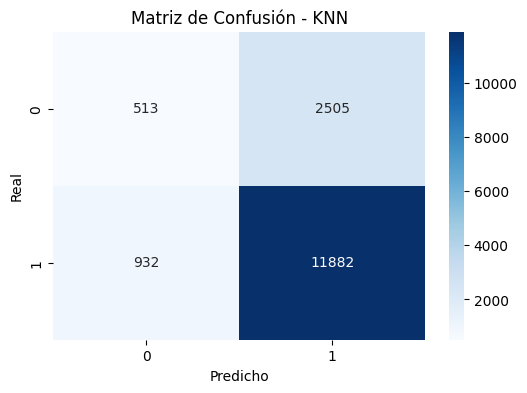

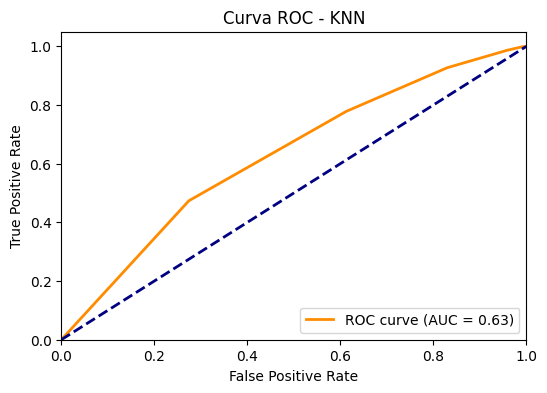

In [6]:
from sklearn.neighbors import KNeighborsClassifier

# Escalado de características (importante para KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definición del modelo KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_knn = knn_model.predict(X_test_scaled)
y_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
print("### Resultados para KNN:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_knn))
print("### Reporte de Clasificación - KNN ###")
print(classification_report(y_test, y_pred_knn))
print("="*50)

# Matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - KNN')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_knn)
roc_auc = roc_auc_score(y_test, y_proba_knn)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC - KNN')
plt.legend(loc="lower right")
plt.show()

### Resultados para Regresión Logística:
Accuracy: 0.6887

Matriz de Confusión:
[[1651 1367]
 [3562 9252]]
### Reporte de Clasificación - Regresión Logística ###
              precision    recall  f1-score   support

           0       0.32      0.55      0.40      3018
           1       0.87      0.72      0.79     12814

    accuracy                           0.69     15832
   macro avg       0.59      0.63      0.60     15832
weighted avg       0.77      0.69      0.72     15832



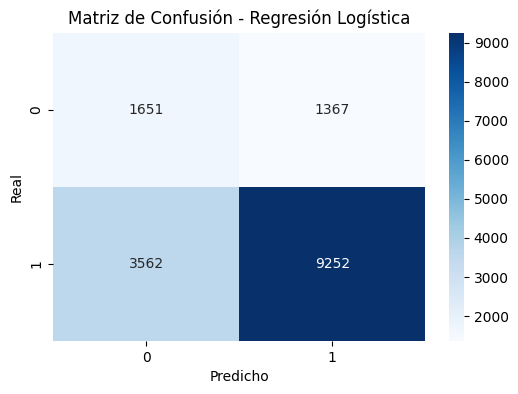

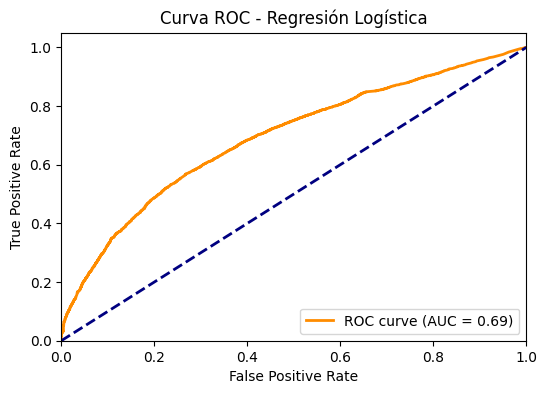

In [7]:
from sklearn.linear_model import LogisticRegression

# Definición del modelo Regresión Logística
lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_model.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test)
y_proba_lr = lr_model.predict_proba(X_test)[:, 1]

# Métricas
print("### Resultados para Regresión Logística:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_lr))
print("### Reporte de Clasificación - Regresión Logística ###")
print(classification_report(y_test, y_pred_lr))
print("="*50)

# Matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
roc_auc = roc_auc_score(y_test, y_proba_lr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.show()

### Resultados para Random Forest:
Accuracy: 0.6884

Matriz de Confusión:
[[1458 1560]
 [3374 9440]]
### Reporte de Clasificación - Random Forest ###
              precision    recall  f1-score   support

           0       0.30      0.48      0.37      3018
           1       0.86      0.74      0.79     12814

    accuracy                           0.69     15832
   macro avg       0.58      0.61      0.58     15832
weighted avg       0.75      0.69      0.71     15832



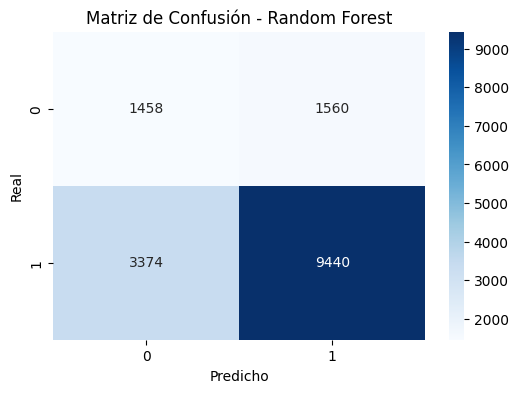

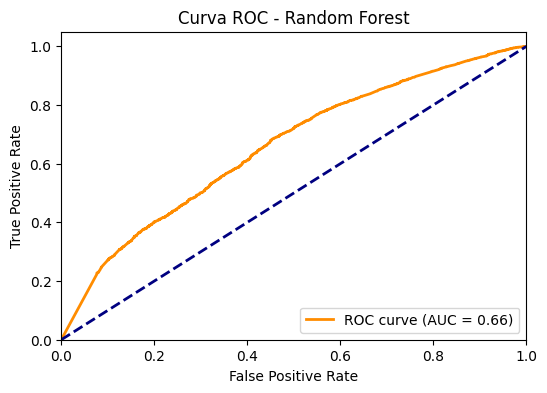

In [8]:
from sklearn.ensemble import RandomForestClassifier
# Definición del modelo Random Forest con balanceo por pesos
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Métricas
print("### Resultados para Random Forest:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print("### Reporte de Clasificación - Random Forest ###")
print(classification_report(y_test, y_pred_rf))
print("="*50)

# Matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_rf)
roc_auc = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.show()

### Resultados para SVM:
Accuracy: 0.7045

Matriz de Confusión:
[[1411 1607]
 [3071 9743]]
### Reporte de Clasificación - SVM ###
              precision    recall  f1-score   support

           0       0.31      0.47      0.38      3018
           1       0.86      0.76      0.81     12814

    accuracy                           0.70     15832
   macro avg       0.59      0.61      0.59     15832
weighted avg       0.75      0.70      0.72     15832



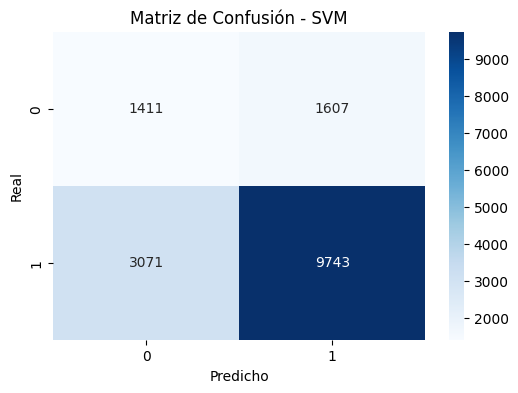

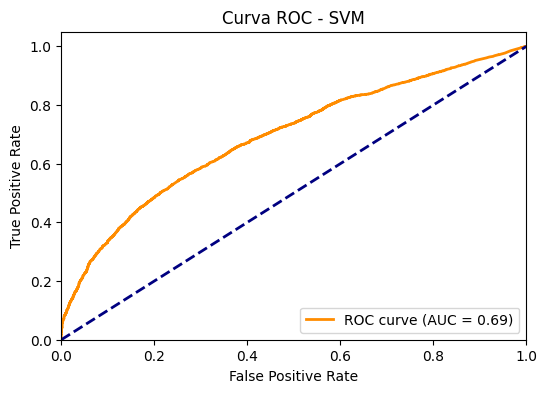

In [9]:
from sklearn.svm import SVC

# Escalado de características (importante para SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definición del modelo SVM SIN probability=True para que sea más rápido
svm_model = SVC(kernel='linear', random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)

# Predicciones
y_pred_svm = svm_model.predict(X_test_scaled)

# Métricas
print("### Resultados para SVM:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred_svm))
print("### Reporte de Clasificación - SVM ###")
print(classification_report(y_test, y_pred_svm))
print("="*50)

# Matriz de confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - SVM')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

# Curva ROC usando decision_function (más eficiente que predict_proba)
y_scores = svm_model.decision_function(X_test_scaled)
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = roc_auc_score(y_test, y_scores)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Curva ROC - SVM')
plt.legend(loc="lower right")
plt.show()

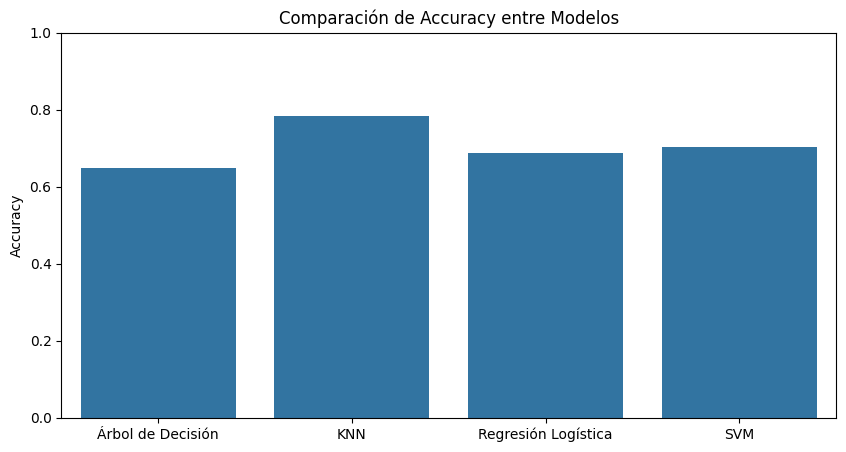

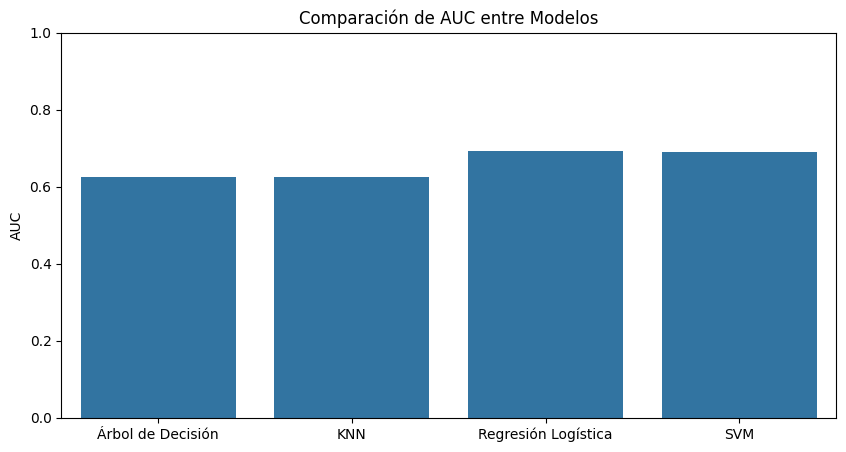

In [11]:
# Comparación de accuracy
models = ['Árbol de Decisión', 'KNN', 'Regresión Logística', 'SVM']
accuracies = [accuracy_score(y_test, y_pred_dt),
              accuracy_score(y_test, y_pred_knn),
              accuracy_score(y_test, y_pred_lr),
              accuracy_score(y_test, y_pred_svm)]

plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=accuracies)
plt.title('Comparación de Accuracy entre Modelos')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

# Comparación de AUC
auc_scores = [roc_auc_score(y_test, y_proba_dt),
              roc_auc_score(y_test, y_proba_knn),
              roc_auc_score(y_test, y_proba_lr),
              roc_auc_score(y_test, y_scores)]

plt.figure(figsize=(10, 5))
sns.barplot(x=models, y=auc_scores)
plt.title('Comparación de AUC entre Modelos')
plt.ylabel('AUC')
plt.ylim(0, 1)
plt.show()